### Source 
https://www.kaggle.com/code/adtysregita/pca-application-using-cifar10-dataset

**What is PCA?**

Principal Component Analysis (PCA), is an algorithm in biometric, also known as Karhunen-Loeve expansion. It is a classical feature extraction and data representation technique widely used for pattern recognition and computer vision. Principal Component Analysis (PCA) treats each image
as an entity. A set of images is needed, which defines a class based on the core feature, derived from those images. A single class can cover a certain number of images. The number of images in a class can be ineffective but the image quality can invariantly impact the overall image analysis results and consequences. PCA is used to avoid computational intense calculations. PCA is a way of identifying patterns in data and expressing the data in a way that highlights its similarities and differences. PCA strives to identify relatively fewer “features” or components that as a whole represent the full object state and hence are appropriately termed “Principal Components”. Thus, principal components extracted by PCA implicitly represent all the features. However, these abstracted features may or may not include a specific feature.

At an abstract level, you take a dataset having many features, and you simplify that dataset by selecting a few *Principal Components* from original features.

**What is Principal Component?**

Principal components are the key to PCA; they represent what's underneath the hood of your data. In a layman term, when the data is projected into a lower dimension (assume three dimensions) from a higher space, the three dimensions are nothing but the three Principal Components that captures (or holds) most of the variance (information) of your data.

Principal components have both direction and magnitude. The direction represents across which principal axes the data is mostly spread out or has most variance and the magnitude signifies the amount of variance that Principal Component captures of the data when projected onto that axis. The principal components are a straight line, and the first principal component holds the most variance in the data. Each subsequent principal component is orthogonal to the last and has a lesser variance. In this way, given a set of x correlated variables over y samples you achieve a set of u uncorrelated principal components over the same y samples.

The reason we achieve uncorrelated principal components from the original features is that the correlated features contribute to the same principal component, thereby reducing the original data features into uncorrelated principal components; each representing a different set of correlated features with different amounts of variation.

Each principal component represents a percentage of total variation captured from the data.

**What is CIFAR10 Dataset?**

The CIFAR-10 (Canadian Institute For Advanced Research) dataset consists of 60000 images each of 32x32x3 color images having ten classes, with 6000 images per category.

The dataset consists of 50000 training images and 10000 test images.

The classes in the dataset are airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

You can download the CIFAR-10 dataset from [here](https://www.cs.toronto.edu/~kriz/cifar.html), or you can also load it on the fly with the help of a deep learning library like **Keras**.

In this project, we will try to apply PCA method into CIFAR-10 dataset and observe the accuracy value.

First of all, let's us import all the necessary libraries. We load the CIFAR-10 dataset using a deep learning library called **Keras**.

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from tensorflow.keras.optimizers import RMSprop
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

Once imported, we will use the **.load_data()** method to download the dataset. It will download and store the data in your **Keras** directory. We can divide the dataset into training data and testing data.

In [2]:
#load dataset from cifar with keras library and load the dataset and store in keras directory
pic_class = keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = pic_class.load_data()

#print the shape of training, testing, and label data
print('Training Data Shape: ', x_train.shape)
print('Testing Data Shape: ', x_test.shape)

print('Label Training Data Shape: ', y_train.shape)
print('Label Testing Data Shape: ', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training Data Shape:  (50000, 32, 32, 3)
Testing Data Shape:  (10000, 32, 32, 3)
Label Training Data Shape:  (50000, 1)
Label Testing Data Shape:  (10000, 1)


We can also find out the total number of labels and the various kinds of classes the dataset has.

In [3]:
#find out total number of labels and classes
classes = np.unique(y_train)
nClasses = len(classes)
print('Number of Outputs: ', nClasses)
print('Number of Output Classes: ', classes)

Number of Outputs:  10
Number of Output Classes:  [0 1 2 3 4 5 6 7 8 9]


Next, let's try to plot the CIFAR-10 images. We can also create a dictionary that will have class names with their corresponding categorical class labels.

In [4]:
#plot images from dataset
%matplotlib inline

label_list = {
    0: 'Airplane',
    1: 'Automobile',
    2: 'Bird',
    3: 'Cat',
    4: 'Deer',
    5: 'Dog',
    6: 'Frog',
    7: 'Horse',
    8: 'Ship',
    9: 'Truck',
}

plt.figure(figsize = [10,10])

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

Text(0.5, 1.0, '(Label: Frog)')
Text(0.5, 1.0, '(Label: Cat)')


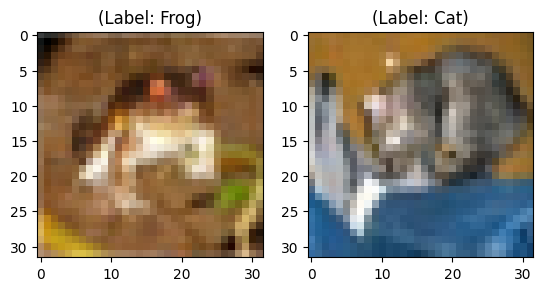

In [5]:
#display 1st image in training data
plt.subplot(121)
curr_img = np.reshape(x_train[0], (32,32,3))
plt.imshow(curr_img)
print(plt.title("(Label: " + str(label_list[y_train[0][0]]) + ")"))

#display 1st image in testing data
plt.subplot(122)
curr_img = np.reshape(x_test[0], (32,32,3))
plt.imshow(curr_img)
print(plt.title("(Label: " + str(label_list[y_test[0][0]]) + ")"))

Even though the above two images are blurry, you can still somehow observe that the first image is a frog with the label **frog** and the second image is a cat with the label **cat**.

Let's check the maximum and minimum values of the CIFAR-10 training images and normalize the pixels between 0 and 1 inclusive.

In [6]:
#check max and min values of dataset
np.min(x_train), np.max(x_train)

(np.uint8(0), np.uint8(255))

In [7]:
#normalize pixels between 0 and 1
x_train = x_train/255.0
np.min(x_train), np.max(x_train)
x_train.shape

(50000, 32, 32, 3)

We will create a dataframe that will hold the pixel values of the images along with their respective labels in a row-column format.

But before that, let's reshape the image dimensions from three to one (flatten the images).

In [8]:
#flatten images
x_train_flat = x_train.reshape(-1,3072)
feat_cols = ['pixel' + str(i) for i in range(x_train_flat.shape[1])]
df_cifar = pd.DataFrame(x_train_flat, columns = feat_cols)
df_cifar['Label'] = y_train
print('Size of Data Frame: {}'.format(df_cifar.shape))

Size of Data Frame: (50000, 3073)


The size of the dataframe is correct, since there are 50,000 training images, each having 3072 pixels and an additional column for labels, so in total 3073.

PCA will be applied on all the columns except the last one, which is the label for each image.

In [9]:
df_cifar.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel3063,pixel3064,pixel3065,pixel3066,pixel3067,pixel3068,pixel3069,pixel3070,pixel3071,Label
0,0.231373,0.243137,0.247059,0.168627,0.180392,0.176471,0.196078,0.188235,0.168627,0.266667,...,0.847059,0.721569,0.549020,0.592157,0.462745,0.329412,0.482353,0.360784,0.282353,6
1,0.603922,0.694118,0.733333,0.494118,0.537255,0.533333,0.411765,0.407843,0.372549,0.400000,...,0.560784,0.521569,0.545098,0.560784,0.525490,0.556863,0.560784,0.521569,0.564706,9
2,1.000000,1.000000,1.000000,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,...,0.305882,0.333333,0.325490,0.309804,0.333333,0.325490,0.313725,0.337255,0.329412,9
3,0.109804,0.098039,0.039216,0.145098,0.133333,0.074510,0.149020,0.137255,0.078431,0.164706,...,0.211765,0.184314,0.109804,0.247059,0.219608,0.145098,0.282353,0.254902,0.180392,4
4,0.666667,0.705882,0.776471,0.658824,0.698039,0.768627,0.694118,0.725490,0.796078,0.717647,...,0.294118,0.309804,0.321569,0.278431,0.294118,0.305882,0.286275,0.301961,0.313725,1


Let's create the PCA method and pass the number of components as two, and apply **fit_transform** on the training data.

In [10]:
#create PCA method
pca_cifar = PCA(n_components = 2)
principalComponents_cifar = pca_cifar.fit_transform(df_cifar.iloc[:, :-1])

Then, we will convert the principal components for each of the 50,000 images from a numpy array to a pandas dataframe.

In [11]:
#convert principal components
principal_cifar_Df = pd.DataFrame(data = principalComponents_cifar,
                                  columns = ['Principal Component 1', 'Principal Component 2'])
principal_cifar_Df['Label'] = y_train
principal_cifar_Df.head()

,Principal Component 1,Principal Component 2,Label
0,-6.401018,2.729039,6
1,0.829783,-0.949943,9
2,7.730200,-11.522102,9
3,-10.347817,0.010738,4
4,-2.625651,-4.969240,1


Now, we will find out the amount of information of **variance** that the principal components hold.

In [12]:
#variance of principal components
print('Explained Variation per Principal Component: {}'.format(pca_cifar.explained_variance_ratio_))

Explained Variation per Principal Component: [0.2907663  0.11253144]


It looks like a decent amount of information was retained by the principal components 1 and 2, given that the data was projected from 3072 dimensions to a mere two principal components.

It's time to visualize the CIFAR-10 data in a two-dimensional space. Remember that there is some semantic class overlap in this dataset, which means that a frog can have a slightly similar shape of a cat or a deer with a dog; especially when projected in a two-dimensional space. The differences between them might not be captured that well.

<Axes: xlabel='Principal Component 1', ylabel='Principal Component 2'>

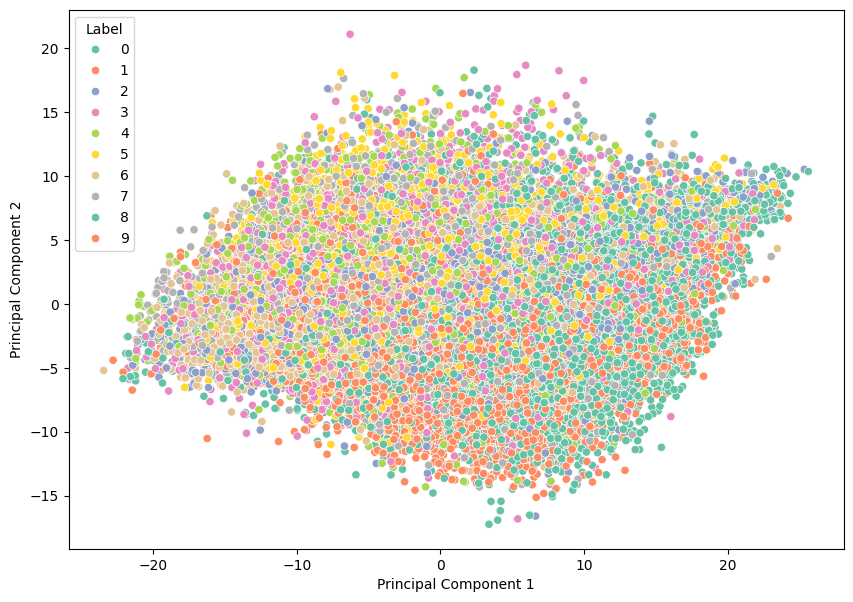

In [13]:
#plotting dataset into 2d graph
plt.figure(figsize = (10,7))
sns.scatterplot(
    x = "Principal Component 1", y = "Principal Component 2",
    hue = "Label",
    palette = sns.color_palette("Set2", 10),
    data = principal_cifar_Df,
    legend = "full",
    alpha = 1.0
)

From the above figure, you can observe that some variation was captured by the principal components, since there is some structure in the points when projected along the two principal component axis. The points belonging to the same class are close to each other, and the points or images that are very different semantically are further away from each other.

Beside data visualization, we can also apply PCA to speed up the machine learning algorithm. First, let's normalize the training and testing images. The training images have been normalized in the PCA visualization, so we only need to normalize and reshape the testing data.

We can also pass how much variance you want PCA to capture. Let's pass 0.99 as a parameter to the PCA model, which means that PCA will hold 99% of the variance and the number of components required to capture 99% variance will be used.

Note that earlier we passed **n_components** as a parameter and you could then find out how much variance was captured by those two components. But, here we explicitly mention how much variance we would like PCA to capture and hence, the **n_components** will vary based on the variance parameter.

If you do not pass any variance, then the number of components will be equal to the original dimension of the data.

In [14]:
#speed up testing process with PCA
#reshape dataset and determine number of variance
x_test = x_test/255.0
x_test = x_test.reshape(-1, 32, 32, 3)
x_test_flat = x_test.reshape(-1, 3072)

Next, fit the PCA instance on the training images and find out how many n_components PCA used to capture 0.99 variance

In [15]:
pca = PCA(0.99)
pca.fit(x_train_flat)
PCA(copy = True, iterated_power = 'auto', n_components = 0.99, random_state = None, svd_solver = 'auto', tol = 0.0, whiten = False)
pca.n_components_

np.int64(658)

From the above output, we can see that to achieve 99% variance, the dimension was reduced to 658 principal components from the actual 3072 dimensions.

Finally, we will apply transform on both the training and testing sets to generate a transformed dataset from the parameters generated from the fit method and convert the training and testing labels to one-hot encoding vector.

In [16]:
train_img_pca = pca.transform(x_train_flat)
test_img_pca = pca.transform(x_test_flat)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

Define the number of epochs, number of classes, and the batch size for our model.

In [17]:
#define batch size, number of classes, and epoch
batch_size = 128
num_classes = 10
epochs = 50

Define the **Sequential** model and print the model summary.

In [18]:
#define Sequential model
model = Sequential()
model.add(Dense(1024, activation = 'relu', input_shape = (658,)))
model.add(Dense(1024, activation = 'relu'))
model.add(Dense(512, activation = 'relu'))
model.add(Dense(256, activation = 'relu'))
model.add(Dense(num_classes, activation = 'softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │       674,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,383,114 (9.09 MB)

 Trainable params: 2,383,114 (9.09 MB)

 Non-trainable params: 0 (0.00 B)

Finally, we can compile and train the model.

In [19]:
#compile and train the model
model.compile(loss = 'categorical_crossentropy',
              optimizer = RMSprop(),
              metrics = ['accuracy'])

history = model.fit(train_img_pca,
                    y_train,
                    batch_size = batch_size,
                    epochs = epochs,
                    verbose = 1,
                    validation_data = (test_img_pca, y_test))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4261 - loss: 1.6244 - val_accuracy: 0.4704 - val_loss: 1.4793
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5573 - loss: 1.2562 - val_accuracy: 0.5359 - val_loss: 1.3224
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6483 - loss: 0.9934 - val_accuracy: 0.5371 - val_loss: 1.3521
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7341 - loss: 0.7437 - val_accuracy: 0.5522 - val_loss: 1.4621
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8147 - loss: 0.5226 - val_accuracy: 0.5404 - val_loss: 1.7182
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8712 - loss: 0.3680 - val_accuracy: 0.5499 - val_loss: 1.9144
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9078 - loss: 0.2658 - val_accuracy: 0.5448 - val_loss: 2.1088
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9322 - loss: 0.1997 - val_accuracy: 0.

From the above output, we can see that the time taken for training each epoch was just 15 seconds on a CPU. The model did a decent job on the training data, achieving 98% accuracy while it achieved only 53% accuracy on the test dat. This means that it overfitted the training data. However, remember that the data was projected to 658 dimensions from 3072 dimensions and despite that, it did a great job.

Finally, let's see how much time the model takes to train on the original dataset and how much accuracy it can achieve using the same deep learning model.

In [20]:
#compile and train full dataset
model = Sequential()
model.add(Dense(1024, activation = 'relu', input_shape = (3072,)))
model.add(Dense(1024, activation = 'relu'))
model.add(Dense(512, activation = 'relu'))
model.add(Dense(256, activation = 'relu'))
model.add(Dense(num_classes, activation = 'softmax'))
model.compile(loss = 'categorical_crossentropy',
              optimizer = RMSprop(),
              metrics = ['accuracy'])

history = model.fit(x_train_flat,
                    y_train,batch_size = batch_size,
                    epochs = epochs,
                    verbose = 1,
                    validation_data = (x_test_flat, y_test))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2419 - loss: 2.1267 - val_accuracy: 0.2495 - val_loss: 2.0235
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3374 - loss: 1.8321 - val_accuracy: 0.3460 - val_loss: 1.7825
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3779 - loss: 1.7294 - val_accuracy: 0.3951 - val_loss: 1.6845
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4042 - loss: 1.6638 - val_accuracy: 0.3939 - val_loss: 1.7236
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4244 - loss: 1.6055 - val_accuracy: 0.4087 - val_loss: 1.6553
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4452 - loss: 1.5532 - val_accuracy: 0.3897 - val_loss: 1.7120
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4578 - loss: 1.5187 - val_accuracy: 0.4187 - val_loss: 1.6791
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4735 - loss: 1.4779 - val_accuracy: 0.

From the above output, it is quite evident that the time taken for training each epoch was around 24 seconds on a CPU, which was almost twice more than the model trained on the PCA output.

Moreover, both the training and testing accuracy is less than the accuracy you achieved with the 658 principal components as an input to the model.

So, by applying PCA on the training data, we were able to train your deep learning algorithm not only **fast**, but it also achieved **better accuracy** on the testing data when compared with the deep learning algorithm trained with original training data.